In [2]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split


In [3]:
path = "/Users/skush/CodeX/Stress-Level-Classifier/data/processed/cleaned_kaggle_v2.csv"

In [4]:
df = pd.read_csv(path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [5]:
df.columns 

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Sleep_Hours',
       'Daily_Screen_Hours', 'Weekend_Screen_Hours', 'Social_Media_Hours',
       'Caffeine_Cups_Per_Day', 'Work_Productivity_Score', 'App_Usage_Count',
       'Exercise_Hours_Per_Week', 'Daily_Work_Hours', 'Commute_Hours_Per_Day',
       'Stress_Level', 'Stressed'],
      dtype='object')

<h3> Irrelevant Columns

In [6]:
irrelevant = ['User_ID', 'Weekend_Screen_Hours', 'Stress_Level']

In [7]:
df = df.drop(columns=irrelevant)

In [8]:
df.Stressed.value_counts()

Stressed
1    2544
0    1413
Name: count, dtype: int64

In [9]:
X = df.drop('Stressed', axis=1)
y = df['Stressed']

In [10]:
X = pd.get_dummies(X, drop_first=True)

<h3> Train Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

<h3> Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3> Logistic Regression Training 

In [13]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train_scaled, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial')

In [14]:
y_pred_log = log_model.predict(X_test_scaled)

<h3> Model Evaluation 

In [15]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Accuracy: 0.8257575757575758
              precision    recall  f1-score   support

           0       0.74      0.78      0.76       424
           1       0.87      0.85      0.86       764

    accuracy                           0.83      1188
   macro avg       0.81      0.82      0.81      1188
weighted avg       0.83      0.83      0.83      1188



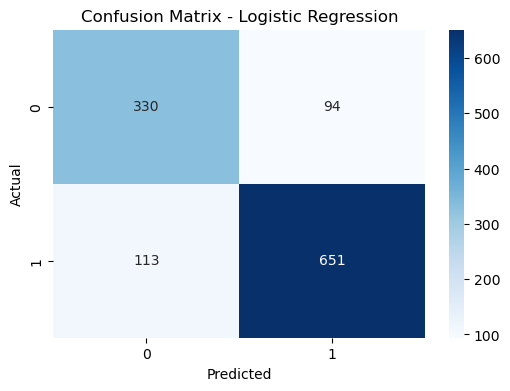

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [17]:
from sklearn.metrics import roc_auc_score

y_prob = log_model.predict_proba(X_test_scaled)[:,1]
roc_auc_score(y_test, y_prob)

np.float64(0.8639175639632519)

In [18]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(log_model, X, y, cv=5, scoring="roc_auc")

print(scores)
print(scores.mean())

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_c

[0.87349268 0.86583546 0.86276108 0.8694074  0.88262708]
0.8708247408462964


In [19]:
import joblib

joblib.dump(log_model, "/Users/skush/CodeX/Stress-Level-Classifier/Models/baseline.pkl")

['/Users/skush/CodeX/Stress-Level-Classifier/Models/baseline.pkl']